In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringStateEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP
import os
print(os.environ.get("XLA_PYTHON_CLIENT_MEM_FRACTION"))
%matplotlib inline

None


# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

## Define the Policy Network

In [4]:
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [5]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Initial Rollout

In [6]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

/home/tong/tongworkspace/paperworkspace/rpg_flightning/flightning/envs/hovering_state_env.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


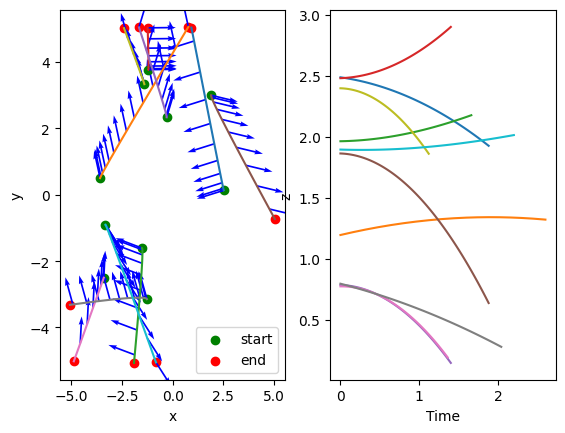

In [7]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [8]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=100,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=100,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

2026-06-10 15:29:43.046019: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-10 15:29:43.046173: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Episode: 0, Loss: 18.96
Episode: 0, Grad max: 1.8003
Episode: 10, Loss: 20.49
Episode: 10, Grad max: 1.0619
Episode: 20, Loss: 10.32
Episode: 20, Grad max: 0.5654
Episode: 30, Loss: 7.50
Episode: 30, Grad max: 1.2070
Episode: 40, Loss: 6.26
Episode: 40, Grad max: 0.2902
Episode: 50, Loss: 5.69
Episode: 50, Grad max: 0.2858
Episode: 60, Loss: 5.55
Episode: 60, Grad max: 0.5712
Episode: 70, Loss: 5.19
Episode: 70, Grad max: 0.3689
Episode: 80, Loss: 5.05
Episode: 80, Grad max: 0.4427
Episode: 90, Loss: 5.14
Episode: 90, Grad max: 0.2963
Training time: 43.06781506538391


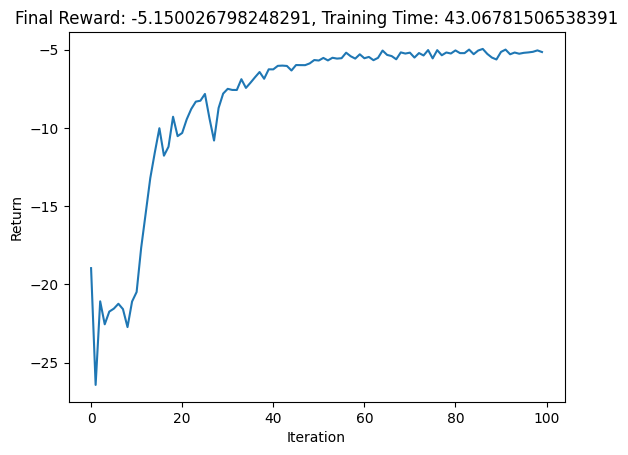

In [9]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [10]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [11]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=10 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

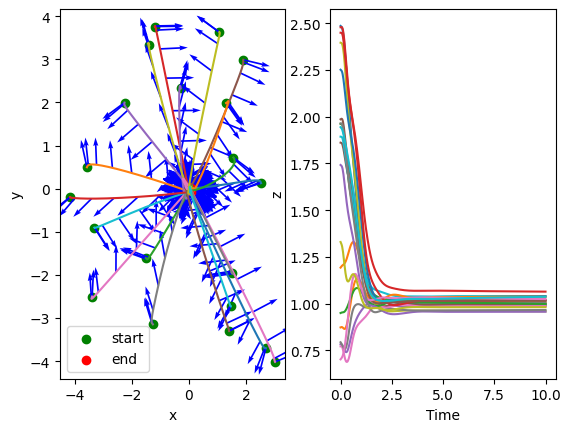

In [12]:
env_eval.plot_trajectories(transitions_eval)